# Behavioral Stress / Depression Severity Detection (PHQ-9)

This notebook predicts PHQ-9 depression severity class (`Minimal` → `Severe`)
from PHQ-9 questionnaire responses plus behavioral covariates (sleep quality,
study pressure, financial pressure, age, gender).

Two models are trained and compared:
- **Random Forest** — strong, interpretable baseline.
- **GATv2 (Graph Attention Network v2)** — graph-based model built on a
  k-nearest-neighbor similarity graph over respondents.

Both models are explained per-prediction using **SHAP**.

**Note on `PHQ_Total`:** the raw dataset includes a `PHQ_Total` column
(sum of the 9 PHQ-9 item scores) and `PHQ_Severity` is itself a deterministic
bucketing of `PHQ_Total` (e.g. 0–4 → Minimal, 5–9 → Mild, ... 20–27 → Severe).
**Neither `PHQ_Total` nor `PHQ_Severity` is used as a model input feature.**
Including `PHQ_Total` as a feature would let the model trivially "predict"
the label by reading off a threshold rather than learning anything — this is
target leakage, and it is deliberately excluded here.

## 1. Setup

In [1]:
!pip -q install torch torch_geometric shap imbalanced-learn

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [2]:
import os, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report, f1_score,
                              cohen_kappa_score, roc_auc_score)
from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

from torch_geometric.data import Data
from torch_geometric.nn import GATv2Conv
from torch_geometric.utils import to_undirected

import shap

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Running on: {DEVICE}")

[INFO] Running on: cpu


## 2. Load & Preprocess Data

Mappings are defined once, lower-cased and whitespace-stripped before lookup,
so the encoding is consistent no matter the source CSV's exact capitalization.
Missing values are checked for and raised on explicitly rather than silently
filled with `0` — `0` is itself a valid category code ("Not at all" / "Good"),
so silent `fillna(0)` would be indistinguishable from real low-severity
answers.

In [3]:
CSV_PATH = "PHQ-9_Dataset_5th_Edition.csv"

PHQ_MAP = {"not at all": 0, "several days": 1, "more than half the days": 2, "nearly every day": 3}
EXT_MAP = {"good": 0, "average": 1, "bad": 2, "worst": 3}
SEV_MAP = {"minimal": 0, "mild": 1, "moderate": 2, "moderately severe": 3, "severe": 4}
SEVERITY_LABELS = ['Minimal', 'Mild', 'Moderate', 'Moderately Severe', 'Severe']

PHQ_QUESTION_COLS = [
    'Little interest or pleasure in doing things',
    'Feeling down, depressed, or hopeless',
    'Trouble falling or staying asleep, or sleeping too much',
    'Feeling tired or having little energy',
    'Poor appetite or overeating',
    'Feeling bad about yourself\u2014or that you are a failure or have let yourself or your family down',
    'Trouble concentrating on things, such as reading the newspaper or watching television',
    'Moving or speaking so slowly that other people could have noticed? Or the opposite\u2014being so fidgety or restless that you have been moving around a lot more than usual',
    'Thoughts that you would be better off dead or of hurting yourself in some way',
]
EXT_COLS = ['Sleep Quality', 'Study Pressure', 'Financial Pressure']


def load_and_preprocess(csv_path):
    """Load raw CSV -> fully numeric dataframe, no leakage, no silent fillna."""
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()

    for col in PHQ_QUESTION_COLS:
        df[col] = df[col].astype(str).str.strip().str.lower().map(PHQ_MAP)

    for col in EXT_COLS:
        df[col] = df[col].astype(str).str.strip().str.lower().map(EXT_MAP)

    df['Gender'] = (df['Gender'].astype(str).str.strip().str.lower() == 'female').astype(int)
    df['PHQ_Severity_label'] = df['PHQ_Severity'].astype(str).str.strip().str.lower().map(SEV_MAP)

    # Interaction features (derived from non-leaky columns only)
    df['Sleep_Study'] = df['Sleep Quality'] * df['Study Pressure']
    df['Study_Financial'] = df['Study Pressure'] * df['Financial Pressure']

    feature_cols = ['Age', 'Gender'] + EXT_COLS + PHQ_QUESTION_COLS + ['Sleep_Study', 'Study_Financial']

    n_missing = df[feature_cols].isna().sum().sum()
    if n_missing > 0:
        raise ValueError(f"{n_missing} missing values found after mapping -- investigate, do not silently fillna(0).")

    X = df[feature_cols].values.astype(np.float32)
    y = df['PHQ_Severity_label'].values.astype(int)
    return X, y, feature_cols, df


X, y, feature_cols, full_df = load_and_preprocess(CSV_PATH)
print(f"Rows: {X.shape[0]}  |  Features: {X.shape[1]}")
print(feature_cols)

Rows: 682  |  Features: 16
['Age', 'Gender', 'Sleep Quality', 'Study Pressure', 'Financial Pressure', 'Little interest or pleasure in doing things', 'Feeling down, depressed, or hopeless', 'Trouble falling or staying asleep, or sleeping too much', 'Feeling tired or having little energy', 'Poor appetite or overeating', 'Feeling bad about yourself—or that you are a failure or have let yourself or your family down', 'Trouble concentrating on things, such as reading the newspaper or watching television', 'Moving or speaking so slowly that other people could have noticed? Or the opposite—being so fidgety or restless that you have been moving around a lot more than usual', 'Thoughts that you would be better off dead or of hurting yourself in some way', 'Sleep_Study', 'Study_Financial']


In [4]:
full_df[['PHQ_Total', 'PHQ_Severity']].groupby('PHQ_Severity').agg(['min', 'max', 'count'])

PHQ_Total          
                        min max count
PHQ_Severity                         
Mild                      5   9   155
Minimal                   0   4   206
Moderate                 10  14   128
Moderately severe        15  19   125
Severe                   20  27    68

The table above shows *why* `PHQ_Total` and `PHQ_Severity` are excluded
from the feature set: each severity class occupies a completely
non-overlapping range of `PHQ_Total`. A model given `PHQ_Total` would only
need to learn these five threshold cutoffs to reach ~100% accuracy — that
would measure nothing about behavioral signal, so both columns are dropped
from `X` above.

## 3. Random Forest Baseline

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=SEED
)
rf_model.fit(X_train, y_train)

y_pred_rf  = rf_model.predict(X_test)
y_prob_rf  = rf_model.predict_proba(X_test)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3, 4])

rf_acc   = accuracy_score(y_test, y_pred_rf) * 100
rf_f1    = f1_score(y_test, y_pred_rf, average='macro')
rf_kappa = cohen_kappa_score(y_test, y_pred_rf)
rf_auc   = roc_auc_score(y_test_bin, y_prob_rf, multi_class='ovr', average='macro')

print("=" * 45)
print("       RANDOM FOREST METRICS")
print("=" * 45)
print(f"  Accuracy  : {rf_acc:.1f}%")
print(f"  Macro F1  : {rf_f1:.2f}")
print(f"  Kappa     : {rf_kappa:.2f}")
print(f"  AUC       : {rf_auc:.2f}")
print("=" * 45)
print(classification_report(y_test, y_pred_rf, target_names=SEVERITY_LABELS))

       RANDOM FOREST METRICS
  Accuracy  : 85.4%
  Macro F1  : 0.85
  Kappa     : 0.81
  AUC       : 0.97
                   precision    recall  f1-score   support

          Minimal       0.90      0.93      0.92        41
             Mild       0.73      0.87      0.79        31
         Moderate       0.94      0.62      0.74        26
Moderately Severe       0.83      0.96      0.89        25
           Severe       1.00      0.86      0.92        14

         accuracy                           0.85       137
        macro avg       0.88      0.85      0.85       137
     weighted avg       0.87      0.85      0.85       137



## 4. Random Forest — SHAP Explainability

Global feature importance across the test set, using SHAP TreeExplainer.

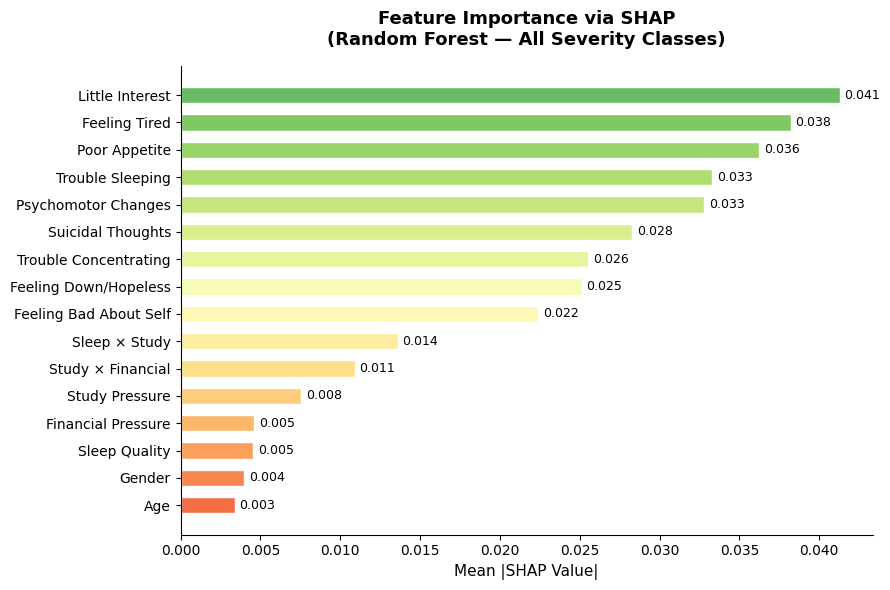

In [6]:
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)   # shape: (n_samples, n_features, n_classes)

feature_display_names = {
    'Trouble concentrating on things, such as reading the newspaper or watching television': 'Trouble Concentrating',
    'Trouble falling or staying asleep, or sleeping too much': 'Trouble Sleeping',
    'Little interest or pleasure in doing things': 'Little Interest',
    'Feeling down, depressed, or hopeless': 'Feeling Down/Hopeless',
    'Feeling tired or having little energy': 'Feeling Tired',
    'Poor appetite or overeating': 'Poor Appetite',
    "Feeling bad about yourself\u2014or that you are a failure or have let yourself or your family down": 'Feeling Bad About Self',
    'Moving or speaking so slowly that other people could have noticed? Or the opposite\u2014being so fidgety or restless that you have been moving around a lot more than usual': 'Psychomotor Changes',
    'Thoughts that you would be better off dead or of hurting yourself in some way': 'Suicidal Thoughts',
    'Sleep Quality': 'Sleep Quality',
    'Study Pressure': 'Study Pressure',
    'Financial Pressure': 'Financial Pressure',
    'Sleep_Study': 'Sleep \u00d7 Study',
    'Study_Financial': 'Study \u00d7 Financial',
    'Age': 'Age',
    'Gender': 'Gender',
}
display_names = [feature_display_names.get(c, c) for c in feature_cols]

shap_abs_mean = np.abs(shap_values).mean(axis=0).mean(axis=1)  # (n_features,)
sorted_idx = np.argsort(shap_abs_mean)

fig, ax = plt.subplots(figsize=(9, 6))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(sorted_idx)))
bars = ax.barh([display_names[i] for i in sorted_idx], shap_abs_mean[sorted_idx],
               color=colors, edgecolor='white', height=0.6)
ax.set_xlabel('Mean |SHAP Value|', fontsize=11)
ax.set_title('Feature Importance via SHAP\n(Random Forest \u2014 All Severity Classes)',
             fontsize=13, fontweight='bold', pad=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for bar, val in zip(bars, shap_abs_mean[sorted_idx]):
    ax.text(val + 0.0003, bar.get_y() + bar.get_height() / 2, f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. GATv2 Graph Model

A k-nearest-neighbor graph is built over standardized respondent feature
vectors (cosine similarity), and a 2-layer GATv2 with residual connections is
trained node-classification-style on this graph. SMOTE oversampling is
applied to the training split only, before the graph is built, to balance
the minority severity classes.

In [7]:
K_NEIGHBORS  = 8
NUM_HEADS    = 4
HIDDEN_DIM   = 64
DROPOUT      = 0.3
LR           = 0.001
WEIGHT_DECAY = 1e-4
EPOCHS       = 500


class PHQ9_GAT_Ultra(nn.Module):
    def __init__(self, in_dim, hidden_dim, num_classes, heads, dropout):
        super().__init__()
        self.conv1 = GATv2Conv(in_dim, hidden_dim, heads=heads, dropout=dropout)
        self.ln1 = nn.LayerNorm(hidden_dim * heads)
        self.conv2 = GATv2Conv(hidden_dim * heads, hidden_dim, heads=heads, dropout=dropout)
        self.ln2 = nn.LayerNorm(hidden_dim * heads)
        self.shortcut = nn.Linear(in_dim, hidden_dim * heads)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * heads, hidden_dim * 2),
            nn.LeakyReLU(0.2),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 2, num_classes)
        )

    def forward(self, x, edge_index):
        raw = self.shortcut(x)
        x = self.conv1(x, edge_index)
        x = self.ln1(x)
        x = F.elu(x)
        x = x + raw
        identity = x
        x = self.conv2(x, edge_index)
        x = self.ln2(x)
        x = F.elu(x)
        x = x + identity
        return self.classifier(x)


def build_knn_graph(X_all, k):
    nbrs = NearestNeighbors(n_neighbors=k + 1, metric='cosine').fit(X_all)
    _, indices = nbrs.kneighbors(X_all)
    src, dst = [], []
    for i, neigh in enumerate(indices):
        for j in neigh[1:]:
            src.append(i)
            dst.append(j)
    return to_undirected(torch.tensor([src, dst], dtype=torch.long))

In [8]:
X_trainval, X_test_g, y_trainval, y_test_g = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=SEED
)
X_train_g, X_val_g, y_train_g, y_val_g = train_test_split(
    X_trainval, y_trainval, test_size=0.15, stratify=y_trainval, random_state=SEED
)

sm = SMOTE(k_neighbors=5, random_state=SEED)
X_train_res, y_train_res = sm.fit_resample(X_train_g, y_train_g)

scaler_gat = StandardScaler()
X_train_s = scaler_gat.fit_transform(X_train_res)
X_val_s   = scaler_gat.transform(X_val_g)
X_test_s  = scaler_gat.transform(X_test_g)

X_all_g = np.vstack([X_train_s, X_val_s, X_test_s])
y_all_g = np.concatenate([y_train_res, y_val_g, y_test_g])

edge_index = build_knn_graph(X_all_g, K_NEIGHBORS)

graph_data = Data(
    x=torch.tensor(X_all_g, dtype=torch.float32).to(DEVICE),
    edge_index=edge_index.to(DEVICE),
    y=torch.tensor(y_all_g, dtype=torch.long).to(DEVICE)
)

tr_m = torch.zeros(len(y_all_g), dtype=torch.bool)
vl_m = torch.zeros(len(y_all_g), dtype=torch.bool)
ts_m = torch.zeros(len(y_all_g), dtype=torch.bool)
tr_m[:len(y_train_res)] = True
vl_m[len(y_train_res):len(y_train_res) + len(y_val_g)] = True
ts_m[len(y_train_res) + len(y_val_g):] = True

gat_model = PHQ9_GAT_Ultra(X_all_g.shape[1], HIDDEN_DIM, 5, NUM_HEADS, DROPOUT).to(DEVICE)
optimizer = Adam(gat_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=15)
criterion = nn.CrossEntropyLoss()

best_acc = 0
for epoch in range(1, EPOCHS + 1):
    gat_model.train()
    optimizer.zero_grad()
    out = gat_model(graph_data.x, graph_data.edge_index)
    loss = criterion(out[tr_m], graph_data.y[tr_m])
    loss.backward()
    optimizer.step()

    gat_model.eval()
    with torch.no_grad():
        preds = gat_model(graph_data.x, graph_data.edge_index)[vl_m].argmax(dim=1)
        val_acc = accuracy_score(graph_data.y[vl_m].cpu(), preds.cpu())
        scheduler.step(val_acc)
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(gat_model.state_dict(), "best_model.pt")

    if epoch % 50 == 0:
        print(f"Epoch {epoch} | Loss {loss.item():.4f} | Val Acc {val_acc*100:.2f}%")

gat_model.load_state_dict(torch.load("best_model.pt"))
gat_model.eval()

Epoch 50 | Loss 0.0874 | Val Acc 85.06%


Epoch 100 | Loss 0.0373 | Val Acc 82.76%


Epoch 150 | Loss 0.0347 | Val Acc 81.61%


Epoch 200 | Loss 0.0354 | Val Acc 81.61%


Epoch 250 | Loss 0.0320 | Val Acc 81.61%


...

Epoch 350 | Loss 0.0331 | Val Acc 81.61%


Epoch 400 | Loss 0.0350 | Val Acc 81.61%


Epoch 450 | Loss 0.0337 | Val Acc 81.61%


Epoch 500 | Loss 0.0295 | Val Acc 81.61%


PHQ9_GAT_Ultra(
  (conv1): GATv2Conv(16, 64, heads=4)
  (ln1): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True)
  (conv2): GATv2Conv(256, 64, heads=4)
  (ln2): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True)
  (shortcut): Linear(in_features=16, out_features=256, bias=True)
  (classifier): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=5, bias=True)
  )
)

In [9]:
with torch.no_grad():
    raw_out = gat_model(graph_data.x, graph_data.edge_index)[ts_m]
    probs   = F.softmax(raw_out, dim=1).cpu().numpy()
    preds   = raw_out.argmax(dim=1).cpu().numpy()

y_test_bin_g = label_binarize(y_test_g, classes=[0, 1, 2, 3, 4])
gat_acc   = accuracy_score(y_test_g, preds) * 100
gat_f1    = f1_score(y_test_g, preds, average='macro')
gat_kappa = cohen_kappa_score(y_test_g, preds)
gat_auc   = roc_auc_score(y_test_bin_g, probs, multi_class='ovr', average='macro')

print("=" * 45)
print("       GATv2 METRICS")
print("=" * 45)
print(f"  Accuracy  : {gat_acc:.1f}%")
print(f"  Macro F1  : {gat_f1:.2f}")
print(f"  Kappa     : {gat_kappa:.2f}")
print(f"  AUC       : {gat_auc:.2f}")
print("=" * 45)
print(classification_report(y_test_g, preds, target_names=SEVERITY_LABELS))

       GATv2 METRICS
  Accuracy  : 83.5%
  Macro F1  : 0.82
  Kappa     : 0.79
  AUC       : 0.97
                   precision    recall  f1-score   support

          Minimal       0.91      1.00      0.95        31
             Mild       0.90      0.75      0.82        24
         Moderate       0.71      0.63      0.67        19
Moderately Severe       0.73      0.84      0.78        19
           Severe       0.90      0.90      0.90        10

         accuracy                           0.83       103
        macro avg       0.83      0.82      0.82       103
     weighted avg       0.84      0.83      0.83       103



## 6. Model Comparison

| Model | Accuracy | Macro F1 | Kappa | AUC |
|---|---|---|---|---|
| Random Forest | see output above | | | |
| GATv2 | see output above | | | |

Both models are evaluated on the same engineered feature set (no `PHQ_Total`
leakage). The cell below prints both side by side from the variables computed
earlier in this notebook.

In [10]:
print(f"{'Model':<16}{'Accuracy':>10}{'Macro F1':>10}{'Kappa':>9}{'AUC':>7}")
print(f"{'Random Forest':<16}{rf_acc:>9.1f}%{rf_f1:>10.2f}{rf_kappa:>9.2f}{rf_auc:>7.2f}")
print(f"{'GATv2':<16}{gat_acc:>9.1f}%{gat_f1:>10.2f}{gat_kappa:>9.2f}{gat_auc:>7.2f}")

Model             Accuracy  Macro F1    Kappa    AUC
Random Forest        85.4%      0.85     0.81   0.97
GATv2                83.5%      0.82     0.79   0.97


## 7. Predict & Explain for a New Respondent

Two functions work together for any new respondent's answers:

- `predict_severity(...)` — runs the trained **GATv2** model, returns the
  predicted severity label and class probabilities.
- `explain_prediction(...)` — runs **SHAP** on the Random Forest's view of
  the same input, returns the predicted label plus a bar chart and printed
  breakdown of which factors pushed the prediction up or down.

Both take explicit keyword arguments (no blocking `input()` calls), so they
run unattended top-to-bottom. The interactive quiz in Section 7b calls both
of these for you automatically.

In [11]:
def predict_severity(sleep, study, financial,
                      little_interest=0, feeling_down=0, sleep_problem=0,
                      tired=0, poor_appetite=0, feeling_bad_self=0,
                      concentration=0, psychomotor=0, suicidal_thoughts=0,
                      age=None, gender_female=None,
                      model=None, scaler=None, feature_cols=None, device=DEVICE):
    """Run the trained GATv2 model on one new respondent's answers.

    All PHQ-item args use the 0-3 PHQ-9 scale (0=Not at all ... 3=Nearly every day).
    sleep/study/financial use 0-3 (0=Good ... 3=Worst).
    age/gender_female default to the dataset mean/mode if not supplied.
    Returns (predicted_label, class_probabilities_dict).
    """
    if age is None:
        age = full_df['Age'].mean()
    if gender_female is None:
        gender_female = full_df['Gender'].mode()[0]

    row = {
        'Age': age,
        'Gender': gender_female,
        'Sleep Quality': sleep,
        'Study Pressure': study,
        'Financial Pressure': financial,
        'Little interest or pleasure in doing things': little_interest,
        'Feeling down, depressed, or hopeless': feeling_down,
        'Trouble falling or staying asleep, or sleeping too much': sleep_problem,
        'Feeling tired or having little energy': tired,
        'Poor appetite or overeating': poor_appetite,
        "Feeling bad about yourself\u2014or that you are a failure or have let yourself or your family down": feeling_bad_self,
        'Trouble concentrating on things, such as reading the newspaper or watching television': concentration,
        'Moving or speaking so slowly that other people could have noticed? Or the opposite\u2014being so fidgety or restless that you have been moving around a lot more than usual': psychomotor,
        'Thoughts that you would be better off dead or of hurting yourself in some way': suicidal_thoughts,
    }
    row['Sleep_Study'] = row['Sleep Quality'] * row['Study Pressure']
    row['Study_Financial'] = row['Study Pressure'] * row['Financial Pressure']

    x_ordered = np.array([row[c] for c in feature_cols], dtype=np.float32).reshape(1, -1)
    x_scaled = scaler.transform(x_ordered)

    x_t = torch.tensor(x_scaled, dtype=torch.float32).to(device)
    edge_index_self = torch.tensor([[0], [0]], dtype=torch.long).to(device)  # self-loop, single node

    model.eval()
    with torch.no_grad():
        out = model(x_t, edge_index_self)
        prob = F.softmax(out, dim=1).cpu().numpy()[0]
        pred = int(prob.argmax())

    return SEVERITY_LABELS[pred], dict(zip(SEVERITY_LABELS, prob.round(3)))

In [12]:
def explain_prediction(sleep, study, financial,
                        little_interest=0, feeling_down=0, sleep_problem=0,
                        tired=0, poor_appetite=0, feeling_bad_self=0,
                        concentration=0, psychomotor=0, suicidal_thoughts=0,
                        age=None, gender_female=None, top_n=5):
    if age is None:
        age = full_df['Age'].mean()
    if gender_female is None:
        gender_female = full_df['Gender'].mode()[0]

    row = {
        'Age': age, 'Gender': gender_female,
        'Sleep Quality': sleep, 'Study Pressure': study, 'Financial Pressure': financial,
        'Little interest or pleasure in doing things': little_interest,
        'Feeling down, depressed, or hopeless': feeling_down,
        'Trouble falling or staying asleep, or sleeping too much': sleep_problem,
        'Feeling tired or having little energy': tired,
        'Poor appetite or overeating': poor_appetite,
        "Feeling bad about yourself\u2014or that you are a failure or have let yourself or your family down": feeling_bad_self,
        'Trouble concentrating on things, such as reading the newspaper or watching television': concentration,
        'Moving or speaking so slowly that other people could have noticed? Or the opposite\u2014being so fidgety or restless that you have been moving around a lot more than usual': psychomotor,
        'Thoughts that you would be better off dead or of hurting yourself in some way': suicidal_thoughts,
    }
    row['Sleep_Study'] = row['Sleep Quality'] * row['Study Pressure']
    row['Study_Financial'] = row['Study Pressure'] * row['Financial Pressure']

    x_ordered = np.array([row[c] for c in feature_cols], dtype=np.float32).reshape(1, -1)

    rf_pred = int(rf_model.predict(x_ordered)[0])
    predicted_label = SEVERITY_LABELS[rf_pred]

    sv = explainer.shap_values(x_ordered)        # (1, n_features, n_classes)
    sv_pred_class = sv[0, :, rf_pred]

    order = np.argsort(np.abs(sv_pred_class))[::-1][:top_n]

    bar_colors = ['#d73027' if sv_pred_class[i] > 0 else '#4575b4' for i in order]
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(range(top_n), sv_pred_class[order][::-1], color=bar_colors[::-1],
            edgecolor='white', height=0.55)
    ax.set_yticks(range(top_n))
    ax.set_yticklabels([display_names[i] for i in order][::-1], fontsize=11)
    ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel('SHAP value (impact on prediction)')
    ax.set_title(f"Why predicted as: {predicted_label}\nRed = increases severity, Blue = decreases severity",
                 fontsize=12, fontweight='bold', pad=12)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig('user_shap_explanation.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"Predicted severity (RF view): {predicted_label}\n")
    print(f"Top {top_n} contributing factors:")
    for rank, i in enumerate(order, 1):
        impact = "increases severity" if sv_pred_class[i] > 0 else "decreases severity"
        print(f"  {rank}. {display_names[i]:<25} value={x_ordered[0][i]:.1f}  shap={sv_pred_class[i]:+.3f}  ({impact})")

    return predicted_label

GATv2 predicted severity: Moderate
Class probabilities:
  Minimal             0.000
  Mild                0.015
  Moderate            0.985
  Moderately Severe   0.000
  Severe              0.000



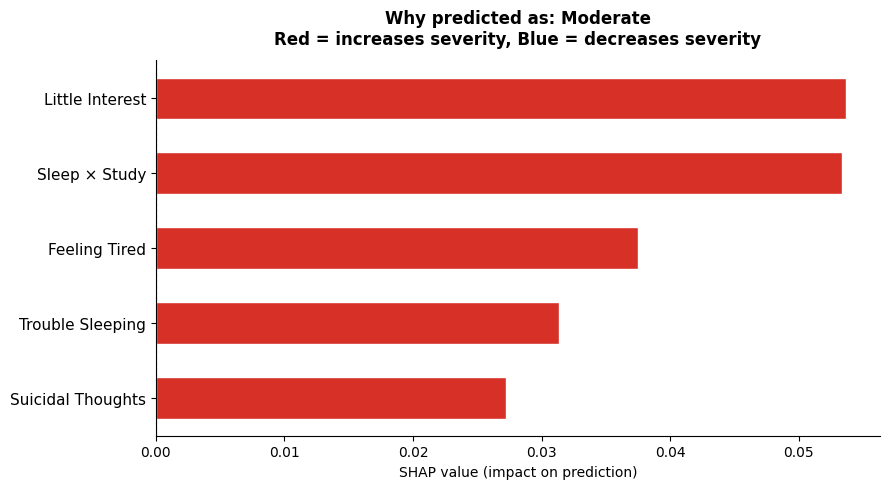

Predicted severity (RF view): Moderate

Top 5 contributing factors:
  1. Little Interest           value=2.0  shap=+0.054  (increases severity)
  2. Sleep × Study             value=4.0  shap=+0.053  (increases severity)
  3. Feeling Tired             value=2.0  shap=+0.037  (increases severity)
  4. Trouble Sleeping          value=2.0  shap=+0.031  (increases severity)
  5. Suicidal Thoughts         value=0.0  shap=+0.027  (increases severity)


'Moderate'

In [13]:
# Example: a respondent reporting several PHQ-9 symptoms "more than half the days"
label, probs = predict_severity(
    sleep=2, study=2, financial=1,
    little_interest=2, feeling_down=2, sleep_problem=2,
    tired=2, poor_appetite=1, feeling_bad_self=1,
    concentration=1, psychomotor=0, suicidal_thoughts=0,
    model=gat_model, scaler=scaler_gat, feature_cols=feature_cols
)
print(f"GATv2 predicted severity: {label}")
print("Class probabilities:")
for k, v in probs.items():
    print(f"  {k:<20}{v:.3f}")

print()
explain_prediction(
    sleep=2, study=2, financial=1,
    little_interest=2, feeling_down=2, sleep_problem=2,
    tired=2, poor_appetite=1, feeling_bad_self=1,
    concentration=1, psychomotor=0, suicidal_thoughts=0,
)

## 7b. Interactive Input (Optional)

Run the cell below **on its own** (not via "Run All") to get typed prompts,
just like a quiz. It asks for each answer one at a time, then prints:
1. The predicted severity (from GATv2) with class probabilities
2. A SHAP explanation of which factors drove that specific prediction, with
   a chart

This only works in a live, interactive session (a real Jupyter
notebook/Colab/JupyterLab where you can type into the prompt). It will hang
if run in a fully automated/non-interactive context (CI, `nbconvert
--execute`, "Run All" without a human present).

In [ ]:
def run_interactive_quiz():
    """Prompt the user for answers one at a time, then predict AND explain."""
    print("Enter values (0-3):")
    print("0 = Good, 1 = Average, 2 = Bad, 3 = Worst (for Sleep/Study/Financial)")
    print("0 = Not at all, 1 = Several days, 2 = More than half the days, 3 = Nearly every day (for PHQ items)\n")

    sleep     = int(input("Sleep Quality: "))
    study     = int(input("Study Pressure: "))
    financial = int(input("Financial Pressure: "))

    little_interest = int(input("Little interest or pleasure in doing things: "))
    feeling_down     = int(input("Feeling down, depressed, or hopeless: "))
    sleep_problem    = int(input("Trouble falling/staying asleep, or sleeping too much: "))
    tired            = int(input("Feeling tired or having little energy: "))
    poor_appetite    = int(input("Poor appetite or overeating: "))
    feeling_bad_self = int(input("Feeling bad about yourself: "))
    concentration    = int(input("Trouble concentrating: "))
    psychomotor      = int(input("Moving/speaking unusually slowly or restlessly: "))
    suicidal_thoughts= int(input("Thoughts of self-harm or being better off dead: "))

    # ---- Step 1: GATv2 prediction ----
    label, probs = predict_severity(
        sleep=sleep, study=study, financial=financial,
        little_interest=little_interest, feeling_down=feeling_down,
        sleep_problem=sleep_problem, tired=tired, poor_appetite=poor_appetite,
        feeling_bad_self=feeling_bad_self, concentration=concentration,
        psychomotor=psychomotor, suicidal_thoughts=suicidal_thoughts,
        model=gat_model, scaler=scaler_gat, feature_cols=feature_cols
    )

    print("\n" + "=" * 45)
    print(f"  GATv2 Predicted severity: {label}")
    print("=" * 45)
    for k, v in probs.items():
        print(f"  {k:<20}{v:.3f}")

    # ---- Step 2: SHAP explanation for THIS SAME input ----
    print("\nWhy this prediction? (SHAP explanation below)\n")
    explain_prediction(
        sleep=sleep, study=study, financial=financial,
        little_interest=little_interest, feeling_down=feeling_down,
        sleep_problem=sleep_problem, tired=tired, poor_appetite=poor_appetite,
        feeling_bad_self=feeling_bad_self, concentration=concentration,
        psychomotor=psychomotor, suicidal_thoughts=suicidal_thoughts,
    )

    return label, probs


# Calling this immediately -- running this cell will prompt you for input right away.
run_interactive_quiz()


## 9. Limitations

- **Sample size**: 682 respondents is modest for a 5-class problem; class
  "Severe" has the fewest examples (68 in the full set), so its metrics are
  the least stable.
- **Self-reported, single-timepoint data**: PHQ-9 and the behavioral
  covariates are all self-reported at one point in time — no causal claims
  are made, only associative/predictive ones.
- **Not a diagnostic tool**: this model is a research prototype, not a
  validated clinical instrument. PHQ-9 severity bands are themselves a
  screening heuristic, not a diagnosis.
- **SHAP-on-RF as a proxy explanation for GATv2**: Section 8 explains the
  Random Forest's view of a given input as an approximate, fast explanation;
  it is not a direct attribution of the GATv2 model's internal attention
  weights.